<a href="https://colab.research.google.com/github/hemoabdullah/PCVK_smst5/blob/main/week11_Hammam_Abdullah_2341720203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Implementasikan 6 metode template matching pada OpenCV dengan
menggunakan gambar cats_and_bunnies.jpg dan cat2_templatejpg.jpg sebagai
templatenya.

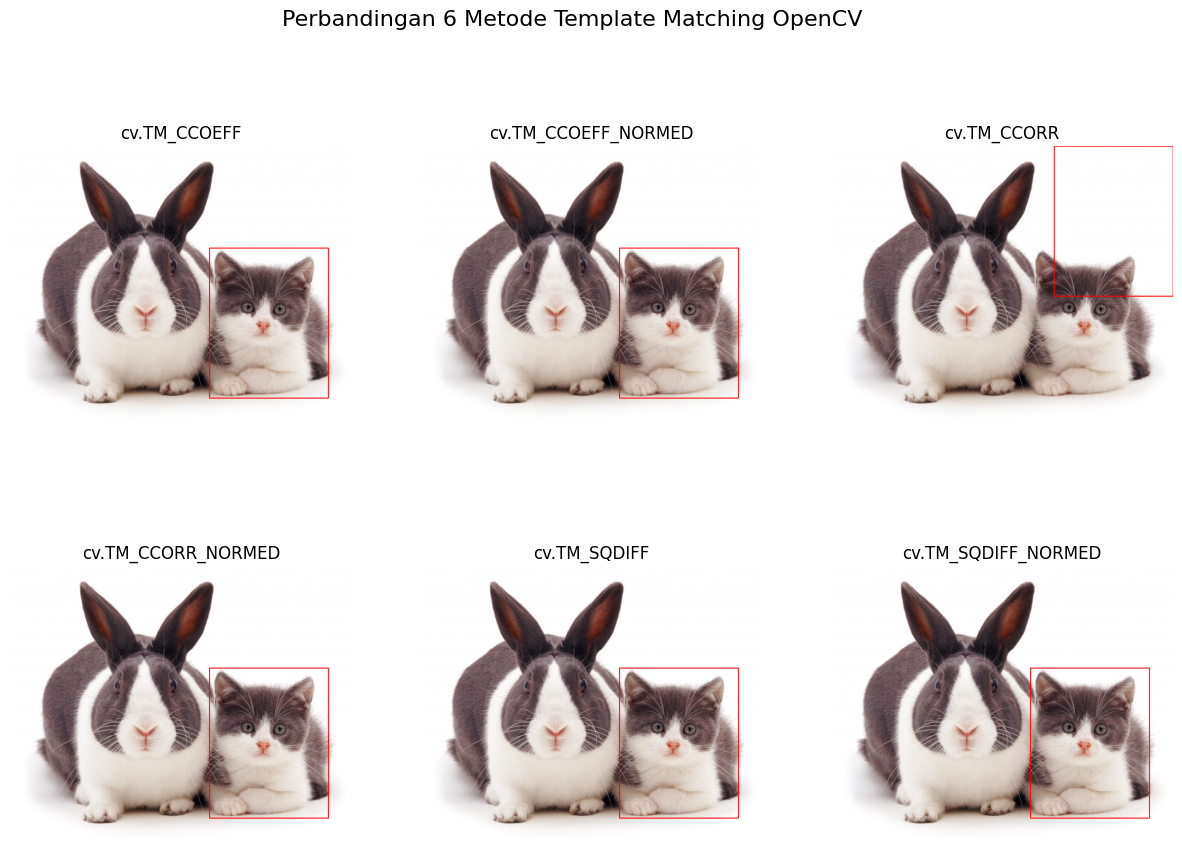

In [ ]:
img_rgb = cv.imread('/content/drive/MyDrive/PCVK/cats_and_bunnies.jpg')
template = cv.imread('/content/drive/MyDrive/PCVK/cat2_templatejpg.jpg')
img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

w, h = template_gray.shape[::-1]

methods = [
    'cv.TM_CCOEFF',
    'cv.TM_CCOEFF_NORMED',
    'cv.TM_CCORR',
    'cv.TM_CCORR_NORMED',
    'cv.TM_SQDIFF',
    'cv.TM_SQDIFF_NORMED'
]

plt.figure(figsize=(15, 10))

# pencocokan template dengan keenam metode
for i, meth in enumerate(methods):
    img_copy = img_rgb.copy()
    method = eval(meth)

    # template matching
    res = cv.matchTemplate(img_gray, template_gray, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    # Menentukan pojok kanan bawah dari kotak hasil deteksi
    bottom_right = (top_left[0] + w, top_left[1] + h)


    cv.rectangle(img_copy, top_left, bottom_right, (0, 0, 255), 2)


    plt.subplot(2, 3, i+1)
    plt.imshow(cv.cvtColor(img_copy, cv.COLOR_BGR2RGB))
    plt.title(meth)
    plt.axis('off')

plt.suptitle('Perbandingan 6 Metode Template Matching OpenCV', fontsize=16)
plt.show()

3. Implementasikan konsep template matching tanpa menggunakan library OpenCV
untuk multiple object, menggunakan gambar bahrain.jpg untuk citra masukan dan
bahrain-template.jpg sebagai citra template, sehingga menghasilkan output
sebagai berikut:

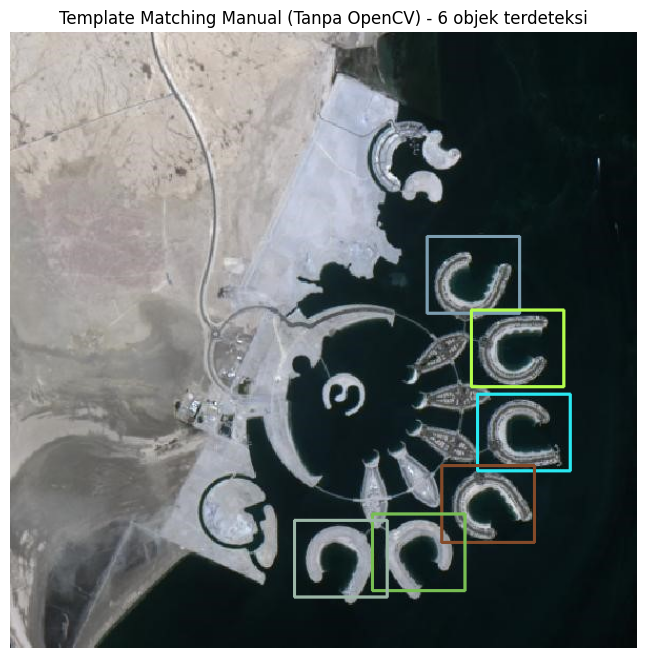

Jumlah objek terdeteksi (unik): 6


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb = cv2.imread('/content/drive/MyDrive/PCVK/bahrain.jpg')
template = cv2.imread('/content/drive/MyDrive/PCVK/bahrain-template.jpg')
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

tH, tW = template_gray.shape

threshold = 0.45  # paling pas 0.45
hasil_deteksi = []

template_norm = (template_gray - np.mean(template_gray)) / (np.std(template_gray) + 1e-6)

for y in range(0, img_gray.shape[0] - tH, 2):
    for x in range(0, img_gray.shape[1] - tW, 2):
        patch = img_gray[y:y+tH, x:x+tW]
        patch_norm = (patch - np.mean(patch)) / (np.std(patch) + 1e-6)
        score = np.mean(patch_norm * template_norm)

        if score > threshold:
            hasil_deteksi.append((x, y, score))

# Filter lokasi yang terlalu dekat(coba coba hasil yang sesuai dengan modul)
final_detections = []
min_distance = tW // 4

for (x, y, s) in hasil_deteksi:
    too_close = False
    for (fx, fy, fs) in final_detections:
        if abs(x - fx) < min_distance and abs(y - fy) < min_distance:
            too_close = True
            break
    if not too_close:
        final_detections.append((x, y, s))

# Gambar hasil
output = img_rgb.copy()
for (x, y, s) in final_detections:
    color = tuple(np.random.randint(0, 255, 3).tolist())
    cv2.rectangle(output, (x, y), (x + tW, y + tH), color, 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Template Matching Manual (Tanpa OpenCV) - {len(final_detections)} objek terdeteksi')
plt.axis('off')
plt.show()

print(f"Jumlah objek terdeteksi (unik): {len(final_detections)}")


4. Implementasikan metode Sobel Edge Detection, Canny Edge
Detection, dan Laplacian Edge Detection pada OpenCV dengan
menggunakan gambar car-park.jpg, sehingga menghasilkan luaran
sebagai berikut:

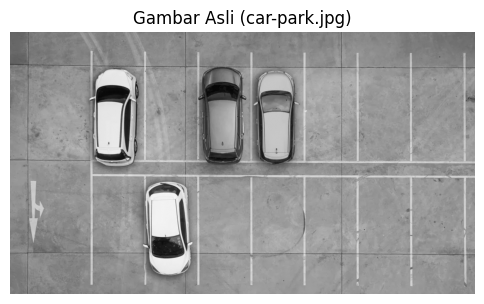

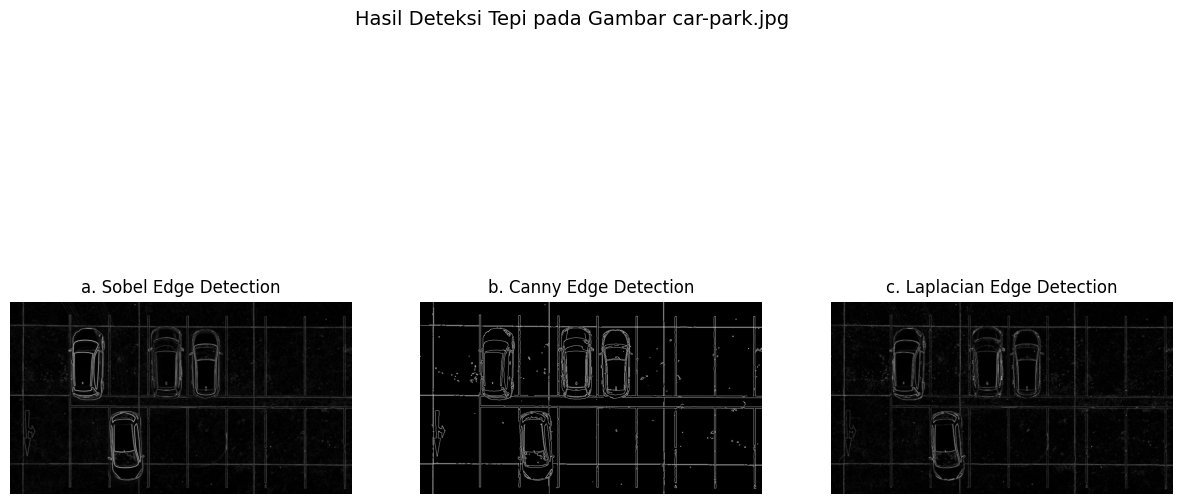

In [ ]:

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/car-park.jpg', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Gambar Asli (car-park.jpg)')
plt.axis('off')
plt.show()

# a. SOBEL EDGE DETECTION

sobelx = cv.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

# b. CANNY EDGE DETECTION
canny = cv.Canny(img, 100, 200)

# c. LAPLACIAN EDGE DETECTION
laplacian = cv.Laplacian(img, cv.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# Tampilkan hasil
plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.imshow(sobel_combined, cmap='gray')
plt.title('a. Sobel Edge Detection')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(canny, cmap='gray')
plt.title('b. Canny Edge Detection')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian, cmap='gray')
plt.title('c. Laplacian Edge Detection')
plt.axis('off')

plt.suptitle('Hasil Deteksi Tepi pada Gambar car-park.jpg', fontsize=14)
plt.show()


5. Implementasikan metode Harris Corner Detection dan Shi-Tomasi

Detection pada OpenCV dengan menggunakan gambar chess-
board.jpg, sehingga menghasilkan luaran sebagai berikut:

a. Harris Corner Detection

b. Shi-Tomasi Detection

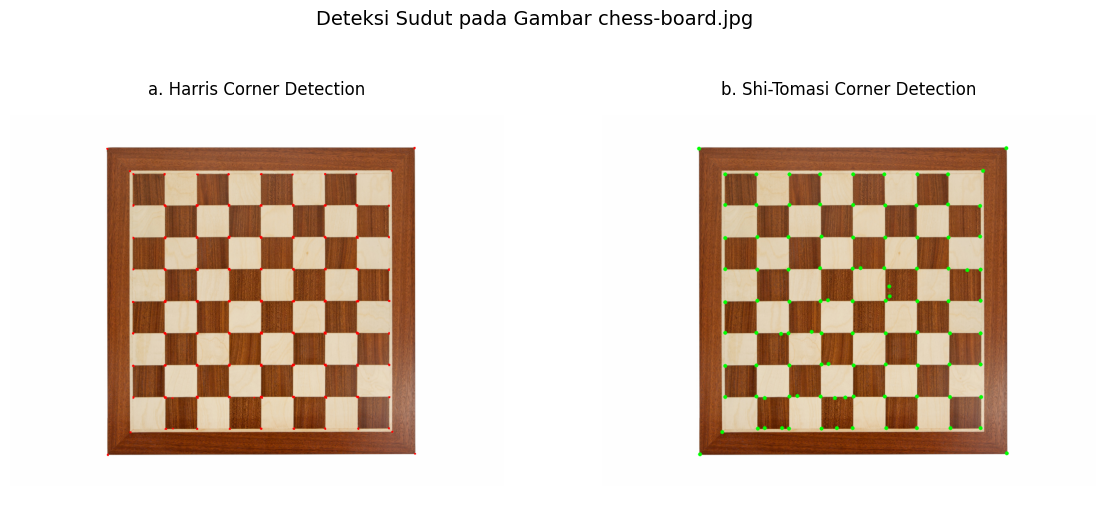

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/chess-board.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# a. HARRIS CORNER DETECTION
gray_float = np.float32(gray)

# Mendeteksi corner dengan Harris
dst = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

# Dilasi untuk memperjelas titik corner
dst = cv2.dilate(dst, None)

# Menandai corner pada gambar
img_harris = img.copy()
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]

# b. SHI-TOMASI CORNER DETECTION
img_shi = img.copy()

# Mendeteksi sudut menggunakan Shi-Tomasi
corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = corners.astype(int)

# Menandai corner pada gambar
for i in corners:
    x, y = i.ravel()
    cv2.circle(img_shi, (x, y), 4, (0, 255, 0), -1)  # titik hijau


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
plt.title('a. Harris Corner Detection')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_shi, cv2.COLOR_BGR2RGB))
plt.title('b. Shi-Tomasi Corner Detection')
plt.axis('off')

plt.suptitle('Deteksi Sudut pada Gambar chess-board.jpg', fontsize=14)
plt.show()


6. Implementasikan metode Hough Transform pada OpenCV dengan
menggunakan gambar sudoku.jpg. Tahapan proses grid detection sesuai yang
terdapat pada ulasan teori, sehingga menghasilkan luaran sebagai berikut:

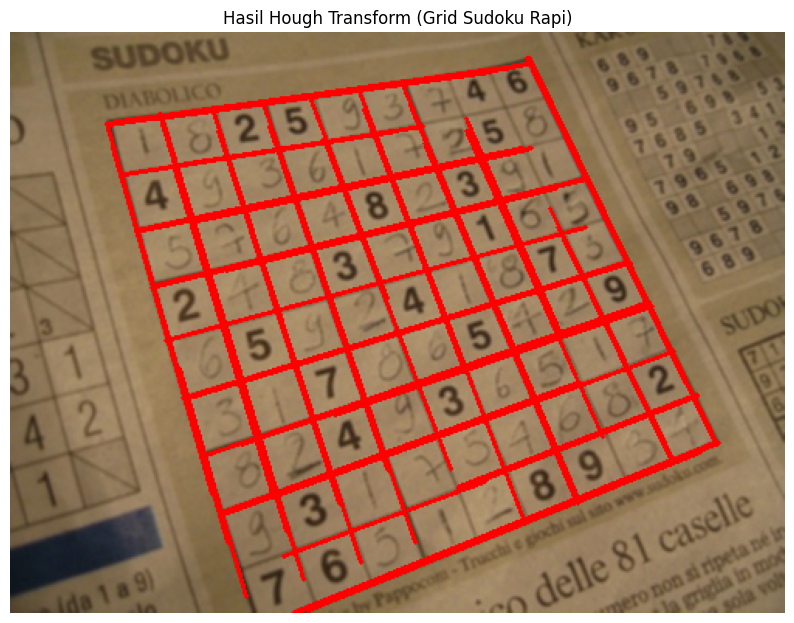

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/sudoku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Canny Edge Detection
edges = cv2.Canny(gray, 100, 200, apertureSize=3)

# 3. Dilasi dan Erosi (supaya garis kotak menyatu, tapi tidak terlalu tebal)
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)
eroded = cv2.erode(dilated, kernel, iterations=1)

# 4. Probabilistic Hough Line Transform (parameter disesuaikan)
linesP = cv2.HoughLinesP(
    eroded,
    rho=1,
    theta=np.pi/180,
    threshold=150,        # lebih tinggi -> hanya garis kuat
    minLineLength=120,    # panjang minimum garis
    maxLineGap=5          # jarak maksimum antar potongan
)

# 5. Gambar garis hasil deteksi
output = img.copy()
if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(output, (x1, y1), (x2, y2), (0, 0, 255), 2)

# 6. Tampilkan hasil
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Hasil Hough Transform (Grid Sudoku Rapi)')
plt.axis('off')
plt.show()


7. Implementasikan fungsi findContours() pada OpenCV untuk contour detection
dengan menggunakan gambar laptop.jpg, sehingga menghasilkan luaran
sebagai berikut:

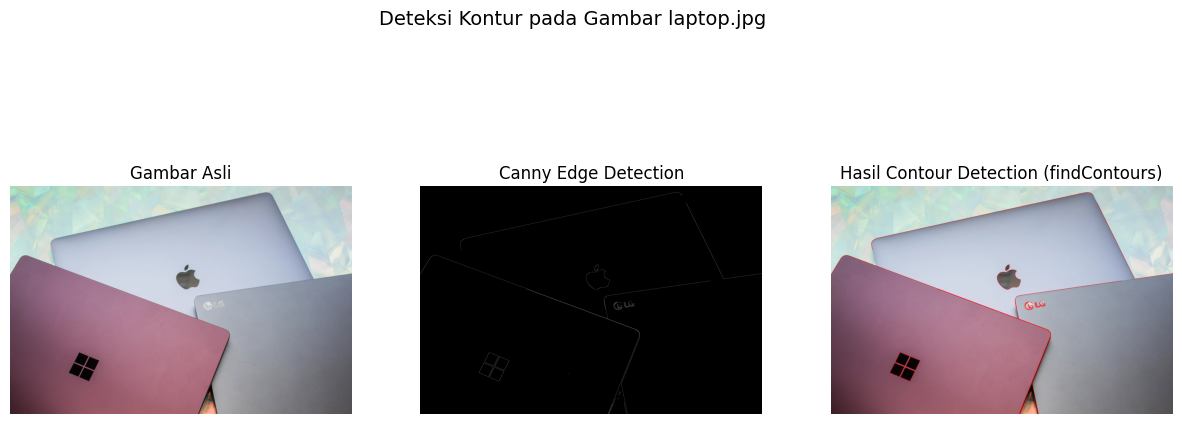

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Baca gambar dan ubah ke grayscale
img = cv2.imread('/content/drive/MyDrive/PCVK/laptop.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2️⃣ Gunakan Gaussian blur untuk mengurangi noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

# 3️⃣ Canny Edge Detection
edges = cv2.Canny(blur, 80, 180)

# 4️⃣ Temukan kontur dari hasil tepi
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5️⃣ Gambar kontur ke gambar asli
img_contours = img.copy()
cv2.drawContours(img_contours, contours, -1, (0, 0, 255), 2)

# 6️⃣ Tampilkan hasil tiap tahap
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title('Hasil Contour Detection (findContours)')
plt.axis('off')

plt.suptitle('Deteksi Kontur pada Gambar laptop.jpg', fontsize=14)
plt.show()


D2. Praktikum Feature Matching dan Face Detection

1. Lakukan Face Detection untuk image object lain yang tersedia pada
(/images/facedet). Tampilkan seperti pada contoh berikut.

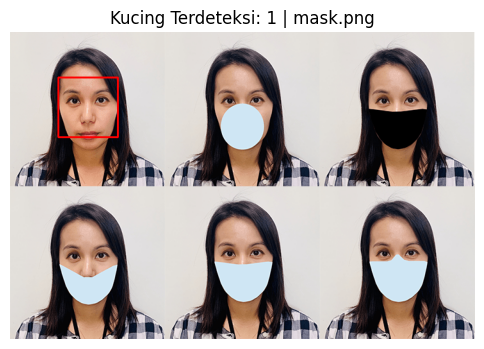

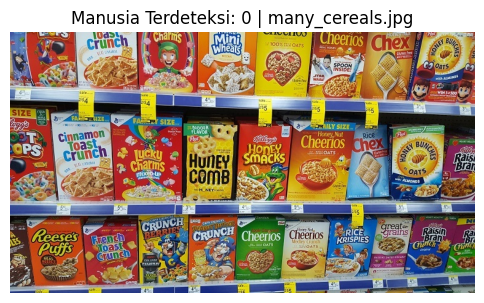

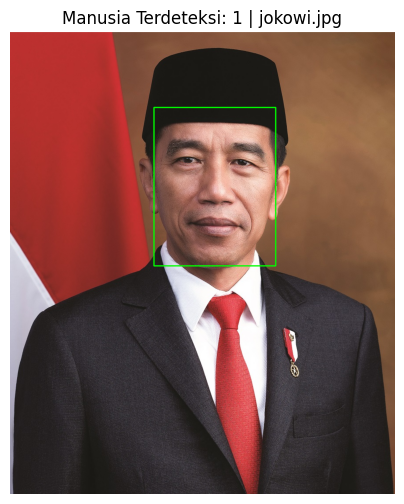

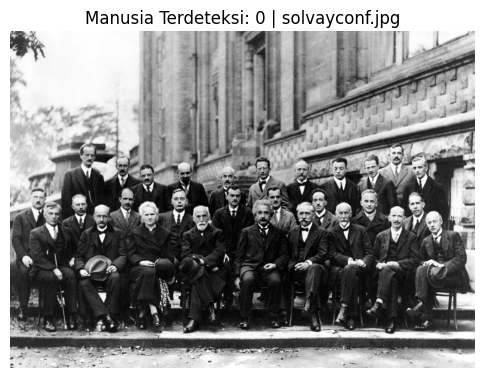

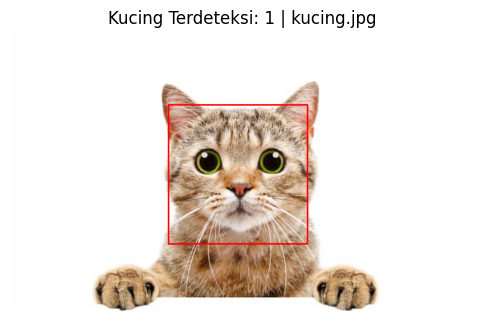

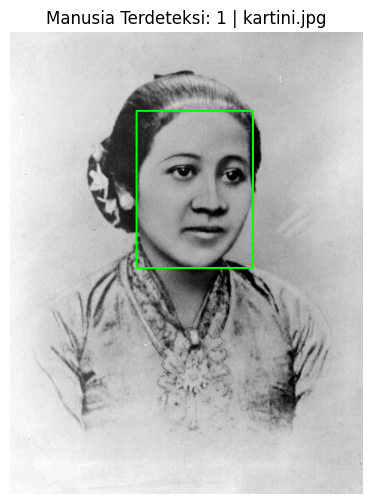

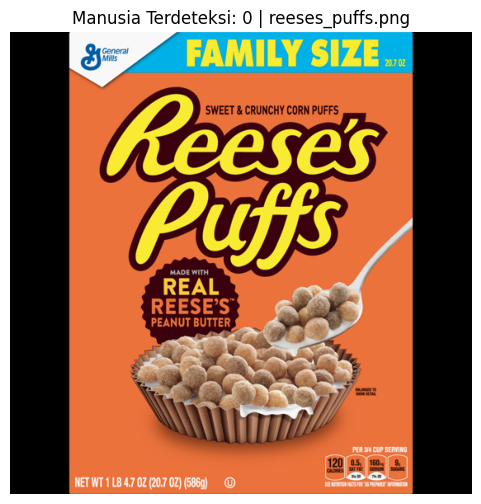

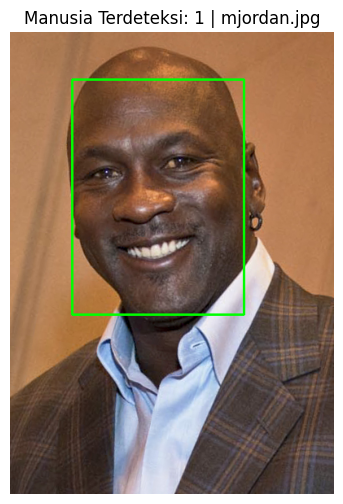

In [45]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# === Load Models ===
# Human face DNN model (SSD)
modelFile = "res10_300x300_ssd_iter_140000_fp16.caffemodel"
configFile = "deploy.prototxt"
net = cv2.dnn.readNetFromCaffe(configFile, modelFile)

# Cat face Haar Cascade
cat_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface_extended.xml')

# === Input Folder ===
folder = "/content/drive/MyDrive/PCVK/Images/facedet"
images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# === Detection Function ===
def detect_faces(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray)

    # Detect cats first
    cats = cat_cascade.detectMultiScale(gray_eq, scaleFactor=1.03, minNeighbors=3, minSize=(50, 50))
    if len(cats) > 0:
        for (x, y, w, h) in cats:
            cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)
        return img, len(cats), "Kucing"

    # If no cats, use DNN for human faces
    (h, w) = img.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104, 177, 123))
    net.setInput(blob)
    detections = net.forward()

    count = 0
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.45:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype("int")
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            count += 1

    return img, count, "Manusia"

# === Process All Images ===
for name in images:
    path = os.path.join(folder, name)
    result_img, count, tipe = detect_faces(path)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{tipe} Terdeteksi: {count} | {name}")
    plt.axis('off')
    plt.show()


2. Pada Soal No.2. wajah kucing tidak bisa dideteksi dengan baik. Lakukan deteksi
wajah kucing hingga muncul rectangle pada bagian wajahnya. Petunjuk pada soal
ini, perhatikan pretrained features yang telah disediakan OpenCV. Gunakan xml
yang ada jika memang telah disediakan. Jika belum ada, coba cari dengan
searching melalui search engines.

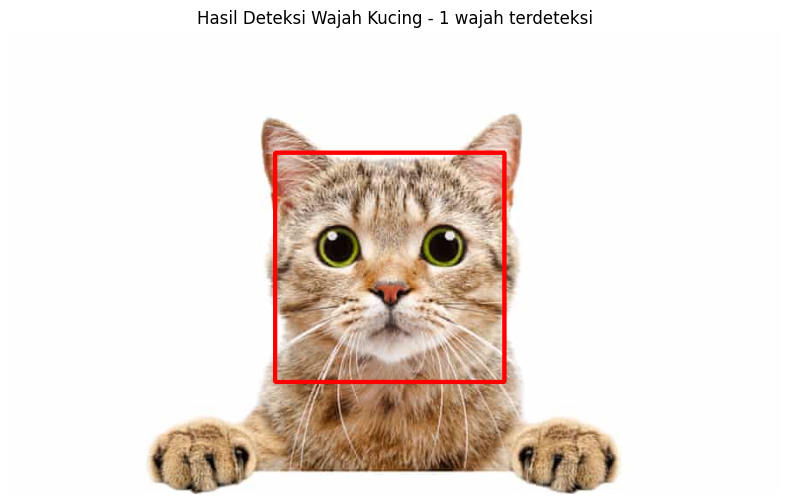

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load the pretrained cat face cascade
cat_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface.xml')

# Read the image (update the path if needed)
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/kucing.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Optional: reduce noise a little
gray = cv2.GaussianBlur(gray, (5,5), 0)

# Detect cat faces
cats = cat_cascade.detectMultiScale(
    gray,
    scaleFactor=1.05,
    minNeighbors=5,     # more strict, fewer false positives
    minSize=(80, 80)
)

# If more than one detection appears, keep only the largest one
if len(cats) > 0:
    # Sort boxes by area (width * height)
    cats = sorted(cats, key=lambda x: x[2]*x[3], reverse=True)
    # Keep only the largest detection
    cats = [cats[0]]

# Draw the rectangle on the image
output = img.copy()
for (x, y, w, h) in cats:
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 0, 255), 3)

# Show the result
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Hasil Deteksi Wajah Kucing - {len(cats)} wajah terdeteksi')
plt.axis('off')
plt.show()


3. Cobakan juga untuk eyes detection pada wajah Pak jokowi:

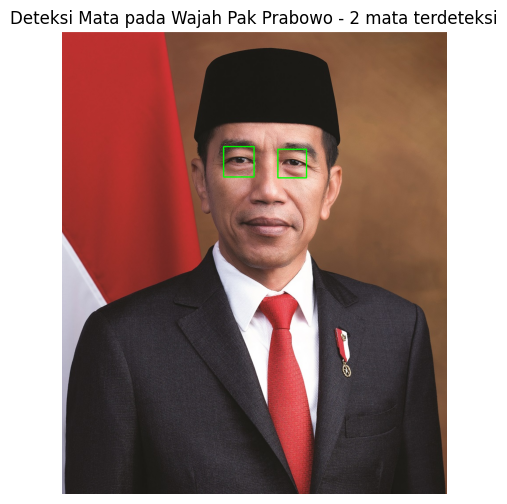

In [11]:
import cv2
import matplotlib.pyplot as plt

# Load pretrained Haar cascades for eyes
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Load image (update path if needed)
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/jokowi.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Optional: slightly increase contrast to make eyes clearer
gray = cv2.convertScaleAbs(gray, alpha=1.2, beta=10)

# Detect eyes directly from the grayscale image
eyes = eye_cascade.detectMultiScale(
    gray,
    scaleFactor=1.05,
    minNeighbors=5,
    minSize=(20, 20),
    maxSize=(80, 80)
)

# Draw green rectangles around detected eyes
output = img.copy()
for (ex, ey, ew, eh) in eyes:
    cv2.rectangle(output, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

# Show result
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Deteksi Mata pada Wajah Pak Prabowo - {len(eyes)} mata terdeteksi')
plt.axis('off')
plt.show()


Success

4. Lakukan deteksi senyuman pada gambar people:

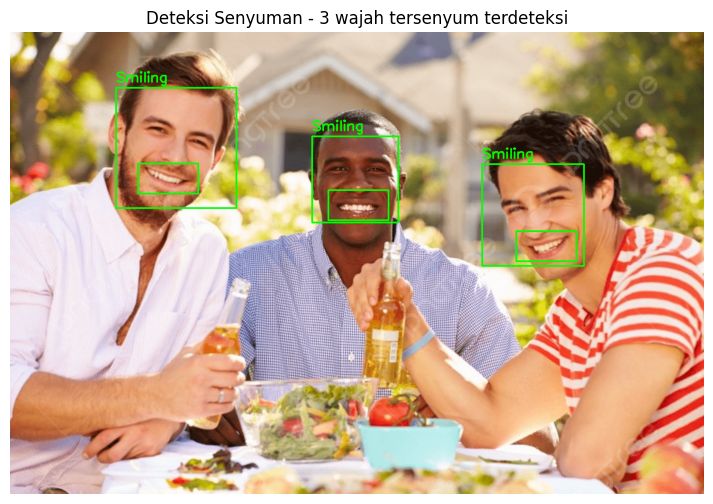

In [17]:
import cv2
import matplotlib.pyplot as plt

# Load Haar cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# Load image
img = cv2.imread('/content/drive/MyDrive/PCVK/Image/friends.jpg')

if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan! Periksa path '/content/drive/MyDrive/PCVK/Images/people.jpg'")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
output = img.copy()

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(80, 80)
)

smile_count = 0

for (x, y, w, h) in faces:
    # ROI for smile: only lower half of the face
    roi_gray = gray[y + h//2:y + h, x:x + w]
    roi_color = output[y + h//2:y + h, x:x + w]

    # Detect smiles in that ROI
    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25)
    )

    if len(smiles) > 0:
        smile_count += 1
        # Draw green rectangle around the entire smiling face
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(output, "Smiling", (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        # Draw smaller green rectangle for the smile area
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 255, 0), 2)

# Show result
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Deteksi Senyuman - {smile_count} wajah tersenyum terdeteksi')
plt.axis('off')
plt.show()


5. Lakukan Face Tracking menggunakan Google Colab. Petunjuk, Tutorial
selengkapnya tentang akses kamera dan FaceDetection pada google colab dapat
dilihat di link berikut: https://www.youtube.com/watch?v=YjWh7QvVH60

In [18]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

In [19]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

In [20]:
# initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))

In [21]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename

<IPython.core.display.Javascript object>

(480, 640)
Saved to photo.jpg


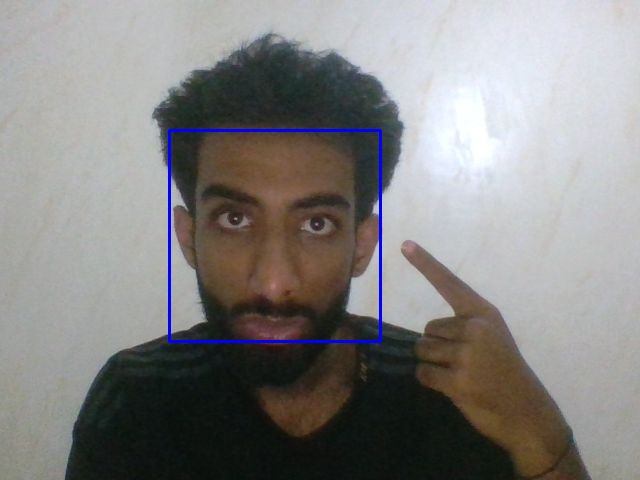

In [36]:
try:
  filename = take_photo('photo.jpg')
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

In [37]:
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

In [ ]:
# start streaming video from webcam
video_stream()
# label for video
label_html = 'Capturing...'
# initialze bounding box to empty
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # convert JS response to OpenCV Image
    img = js_to_image(js_reply["img"])

    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # grayscale image for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # get face region coordinates
    faces = face_cascade.detectMultiScale(gray)
    # get face bounding box for overlay
    for (x,y,w,h) in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes

<IPython.core.display.Javascript object>

/tmp/ipython-input-480462610.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


6. Lakukan Blurring pada bagian wajah yang terdeteksi. Berikut contoh keluarannya.
Petunjuk: anda dapat menggunakan cv.medianBlur untuk melakukan Blurring

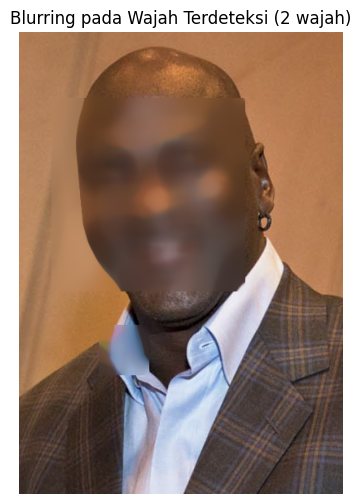

In [39]:
import cv2
import matplotlib.pyplot as plt

# 1️⃣ Load pretrained face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2️⃣ Baca gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/mjordan.jpg')  # ganti sesuai file kamu
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3️⃣ Deteksi wajah
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# 4️⃣ Lakukan blurring di area wajah
output = img.copy()
for (x, y, w, h) in faces:
    face_region = output[y:y+h, x:x+w]
    # Gunakan median blur
    blurred_face = cv2.medianBlur(face_region, 35)   # semakin besar kernel → semakin blur
    output[y:y+h, x:x+w] = blurred_face

# 5️⃣ Tampilkan hasil
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Blurring pada Wajah Terdeteksi ({len(faces)} wajah)')
plt.axis('off')
plt.show()


7. Mengolah gambar KTM masing-masing
a. Berikut ini contoh KTM
b. Tampilkan Foto KTM seperti contoh berikut ini:
c. Lakukan Deteksi Obyek KTM pada gambar yang berisi KTM dengan
barang lainnya dengan menggunakan Konsep Feature Matching

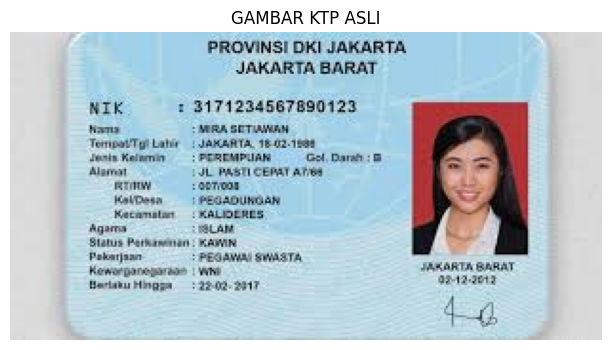

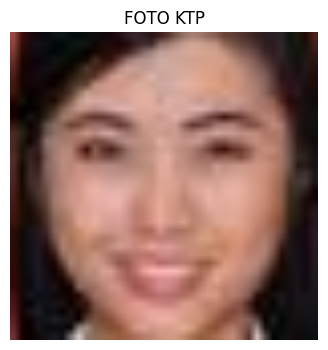

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/PCVK/KTP.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.imshow(img_rgb)
plt.title("GAMBAR KTP ASLI")
plt.axis('off')
plt.show()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

if len(faces) > 0:
    for (x, y, w, h) in faces:
        roi = img[y:y+h, x:x+w]
        foto_ktm = cv2.resize(roi, (250, 250))
else:
    foto_ktm = img[130:380, 40:280]
    foto_ktm = cv2.resize(foto_ktm, (250, 250))

foto_ktm_rgb = cv2.cvtColor(foto_ktm, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(foto_ktm_rgb)
plt.title("FOTO KTP")
plt.axis('off')
plt.show()
w

Tambahan Tugas Praktikum:
Tampilkan karakter-karakter pada KTM ini Deep Learning untuk melakukan
pengenalan karakter. Sebelum melakukan training data, terlebih dahulu di
siapkan data yang akan dilakukan training yaitu data image nomor angka 0-9.
Untuk membuat data tersebut bisa gunakan image editor untuk dilakukan croping
satu persatu. Kemudian selanjutnya gunakan source code di bawah ini untuk
proses persiapan untuk training.

In [48]:
!pip install tensorflow opencv-python matplotlib
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


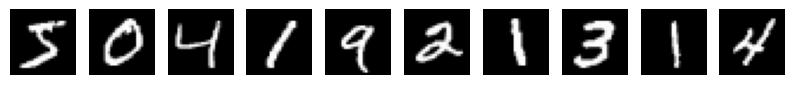

In [49]:
# Load MNIST dataset (handwritten digits)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize (convert pixel 0–255 to 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension (for CNN input)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Show sample digits
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9147 - loss: 0.2827 - val_accuracy: 0.9857 - val_loss: 0.0443
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 34ms/step - accuracy: 0.9848 - loss: 0.0479 - val_accuracy: 0.9901 - val_loss: 0.0302
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9910 - loss: 0.0277 - val_accuracy: 0.9899 - val_loss: 0.0317
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9939 - loss: 0.0199 - val_accuracy: 0.9919 - val_loss: 0.0302
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9958 - loss: 0.0133 - val_accuracy: 0.9890 - val_loss: 0.0330


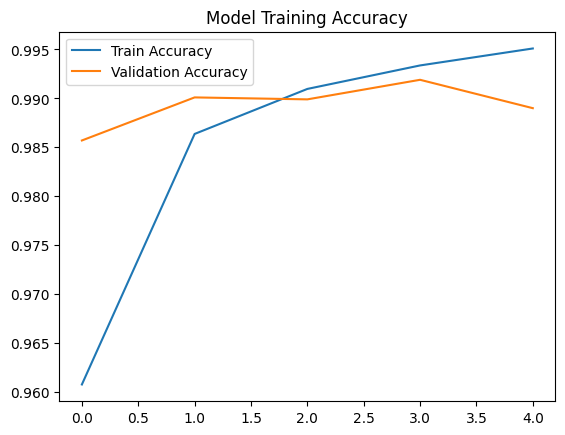

In [50]:
# Create CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Save model
model.save("/content/model_digit_ktm.h5")

# Show accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Training Accuracy')
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load model
model = load_model("/content/model_digit_ktm.h5")

# Take one image from test data
test_index = 7
test_img = x_test[test_index]
plt.imshow(test_img.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

# Predict
pred = model.predict(np.expand_dims(test_img, axis=0))
print("Predicted digit:", np.argmax(pred))
print("Actual digit:", y_test[test_index])
